# Vision Mamba (Vim) Training - Drone RF Spectrogram Classification

Training protocol: Document_9_Training_Strategy_Protocol.md

Architecture: Vision Mamba with bidirectional selective state space model

Dataset: VTI DroneSET RF spectrograms (2.4 GHz + 5.8 GHz)

Tasks: drone_type (3), flight_mode (5), drone_count (3)

| Component | Specification |
|---|---|
| Patch Embedding | Conv2d(3, 384, 16, stride=16) |
| CLS Token | Learnable, prepended |
| Position Embedding | Learnable, shape (1, 197, 384) |
| Encoder | 24 bidirectional VimBlocks |
| VimBlock | Pre-LayerNorm, Forward Mamba, Backward Mamba, Residual |
| Classification | LayerNorm(CLS) then MultiTaskHead(384) |

In [1]:
%%capture
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip uninstall -y mamba-ssm causal-conv1d torch torchvision torchaudio
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu124
import os
os.environ['MAX_JOBS'] = '4'
!pip install causal-conv1d>=1.4.0 --no-build-isolation
!pip install mamba-ssm --no-build-isolation

Found existing installation: torch 2.8.0+cu126
Uninstalling torch-2.8.0+cu126:
  Successfully uninstalled torch-2.8.0+cu126
Found existing installation: torchvision 0.23.0+cu126
Uninstalling torchvision-0.23.0+cu126:
  Successfully uninstalled torchvision-0.23.0+cu126
Found existing installation: torchaudio 2.8.0+cu126
Uninstalling torchaudio-2.8.0+cu126:
  Successfully uninstalled torchaudio-2.8.0+cu126
Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 115.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 57.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 96.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import os
import json
import pickle
import shutil
import math
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple
from datetime import datetime
from collections import Counter
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import torchvision.transforms as transforms

from mamba_ssm import Mamba

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f'Device: {device}')
print(f'Available GPUs: {num_gpus}')
if torch.cuda.is_available():
    for i in range(num_gpus):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')
use_multi_gpu = num_gpus > 1

Device: cuda
Available GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [5]:
@dataclass
class Config:
    """Training configuration for Vision Mamba on VTI DroneSET."""

    img_size: int = 224
    patch_size: int = 16
    in_channels: int = 3

    num_drone_types: int = 3
    num_flight_modes: int = 5
    num_drone_counts: int = 3

    embed_dim: int = 384
    depth: int = 24
    d_state: int = 16
    d_conv: int = 4
    expand: int = 2
    drop_rate: float = 0.1

    batch_size: int = 32
    learning_rate: float = 1e-4
    weight_decay: float = 0.01
    epochs: int = 60
    patience: int = 15
    grad_clip_norm: float = 1.0
    label_smoothing: float = 0.1

    data_root: str = '/kaggle/input/datasets/subratcodesmodels/spectrogram-new-vti/noisy_spectrograms'
    bands: Tuple[str, ...] = ('2.4GHz', '5.8GHz')

    train_snr_levels: Tuple[str, ...] = ('snr_clean', 'snr_+05dB', 'snr_+15dB')
    val_snr_levels: Tuple[str, ...] = ('snr_+00dB',)
    test_snr_levels: Tuple[str, ...] = ('snr_clean', 'snr_+10dB', 'snr_+20dB')

    models: List[str] = field(default_factory=lambda: ['vim'])


config = Config()
TASKS = ['drone_type', 'flight_mode', 'drone_count']
print('Configuration initialized')
print(f'  Image: {config.img_size}x{config.img_size}, Patch: {config.patch_size}')
print(f'  Embed dim: {config.embed_dim}, Depth: {config.depth}')
print(f'  SSM: d_state={config.d_state}, d_conv={config.d_conv}, expand={config.expand}')
print(f'  Batch size: {config.batch_size}')
print(f'  Epochs: {config.epochs}, Patience: {config.patience}')
print(f'  Train SNR: {config.train_snr_levels}')
print(f'  Val SNR: {config.val_snr_levels}')
print(f'  Test SNR: {config.test_snr_levels}')

Configuration initialized
  Image: 224x224, Patch: 16
  Embed dim: 384, Depth: 24
  SSM: d_state=16, d_conv=4, expand=2
  Batch size: 32
  Epochs: 60, Patience: 15
  Train SNR: ('snr_clean', 'snr_+05dB', 'snr_+15dB')
  Val SNR: ('snr_+00dB',)
  Test SNR: ('snr_clean', 'snr_+10dB', 'snr_+20dB')


## Data Loading

SNR-based partitioning across 2.4 GHz and 5.8 GHz bands.

BUI filename encoding: EEDDMMM (7 bits)
- Bits 0-1: Drone Count (01=1, 10=2, 11=3), subtract 1 for 0-indexed
- Bits 2-3: Drone Type
- Bits 4-6: Flight Mode

| Split | SNR Levels | Fraction |
|---|---|---|
| Train | clean, +05dB, +15dB | 80% stratified |
| Validation | +00dB | 100% |
| Test | clean, +10dB, +20dB | held-out 20% / 100% |

In [6]:
def decode_bui_filename(filename):
    """Extracts drone_type, flight_mode, drone_count from BUI-encoded filename."""
    base = Path(filename).stem.split('_snr')[0]
    return {
        'drone_type': int(base[2:4], 2),
        'flight_mode': int(base[4:7], 2),
        'drone_count': int(base[0:2], 2) - 1,
    }


def load_snr_folder(data_root, band, snr_level):
    """Loads image paths and labels from a single band/SNR folder."""
    images_dir = Path(data_root) / band / snr_level / 'images'
    if not images_dir.exists():
        print(f'  Not found: {images_dir}')
        return [], [], [], []
    image_paths = sorted(list(images_dir.glob('*.png')))
    if len(image_paths) == 0:
        print(f'  No .png files in: {images_dir}')
        return [], [], [], []
    labels = [decode_bui_filename(p.name) for p in image_paths]
    paths = [str(p) for p in image_paths]
    y_dt = [l['drone_type'] for l in labels]
    y_fm = [l['flight_mode'] for l in labels]
    y_dc = [l['drone_count'] for l in labels]
    return paths, y_dt, y_fm, y_dc


def load_partition(data_root, bands, snr_levels):
    """Loads and combines data from multiple bands and SNR levels into one partition."""
    all_paths, all_dt, all_fm, all_dc, all_snr = [], [], [], [], []
    for band in bands:
        for snr in snr_levels:
            paths, dt, fm, dc = load_snr_folder(data_root, band, snr)
            all_paths.extend(paths)
            all_dt.extend(dt)
            all_fm.extend(fm)
            all_dc.extend(dc)
            all_snr.extend([snr] * len(paths))
            print(f'  {band}/{snr}: {len(paths)} images')
    return all_paths, np.array(all_dt), np.array(all_fm), np.array(all_dc), np.array(all_snr)


print('=' * 60)
print('DATASET DIAGNOSTICS')
print('=' * 60)
print(f'Data root: {config.data_root}')

input_path = Path('/kaggle/input')
if input_path.exists():
    print(f'\nContents of /kaggle/input:')
    for item in sorted(input_path.iterdir()):
        print(f'  {item.name}/')
        if item.is_dir():
            for sub in list(item.iterdir())[:5]:
                print(f'    {sub.name}')
            if len(list(item.iterdir())) > 5:
                print(f'    ... ({len(list(item.iterdir()))} total items)')
else:
    print('\n/kaggle/input does NOT exist')

data_path = Path(config.data_root)
if data_path.exists():
    print(f'\nContents of {config.data_root}:')
    for item in sorted(data_path.iterdir()):
        print(f'  {item.name}/')
        if item.is_dir():
            for sub in sorted(item.iterdir()):
                print(f'    {sub.name}/')
else:
    print(f'\nData root does NOT exist: {config.data_root}')

print('=' * 60)

print('\nLoading training partition (full):')
all_train_paths, all_train_dt, all_train_fm, all_train_dc, all_train_snr = load_partition(
    config.data_root, config.bands, config.train_snr_levels
)
print(f'Total training-SNR samples: {len(all_train_paths)}')

indices = np.arange(len(all_train_paths))
train_idx, heldout_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=all_train_dt
)
train_idx = sorted(train_idx)
heldout_idx = sorted(heldout_idx)

train_paths = [all_train_paths[i] for i in train_idx]
train_dt = all_train_dt[train_idx]
train_fm = all_train_fm[train_idx]
train_dc = all_train_dc[train_idx]

heldout_paths = [all_train_paths[i] for i in heldout_idx]
heldout_dt = all_train_dt[heldout_idx]
heldout_fm = all_train_fm[heldout_idx]
heldout_dc = all_train_dc[heldout_idx]
heldout_snr = all_train_snr[heldout_idx]

print(f'Training samples (80%): {len(train_paths)}')
print(f'Held-out samples (20%): {len(heldout_paths)}')
print(f'Held-out per SNR: {dict(Counter(heldout_snr.tolist()))}')

print('\nLoading validation partition:')
val_paths, val_dt, val_fm, val_dc, _ = load_partition(
    config.data_root, config.bands, config.val_snr_levels
)
print(f'Validation samples: {len(val_paths)}')

if len(train_paths) == 0:
    raise ValueError('No training images found. Check dataset paths above.')

print(f'\nDrone Type distribution (train 80%): {Counter(train_dt.tolist())}')
print(f'Flight Mode distribution (train 80%): {Counter(train_fm.tolist())}')
print(f'Drone Count distribution (train 80%): {Counter(train_dc.tolist())}')

DATASET DIAGNOSTICS
Data root: /kaggle/input/datasets/subratcodesmodels/spectrogram-new-vti/noisy_spectrograms

Contents of /kaggle/input:
  datasets/
    subratcodesmodels

Contents of /kaggle/input/datasets/subratcodesmodels/spectrogram-new-vti/noisy_spectrograms:
  2.4GHz/
    axis_metadata.json/
    metadata_all_snr.csv/
    snr_+00dB/
    snr_+05dB/
    snr_+10dB/
    snr_+15dB/
    snr_+20dB/
    snr_clean/
    snr_comparison_0100011.png/
    y_drone_type.npy/
    y_mode.npy/
    y_num_drones.npy/
    y_snr.npy/
  5.8GHz/
    axis_metadata.json/
    metadata_all_snr.csv/
    snr_+00dB/
    snr_+05dB/
    snr_+10dB/
    snr_+15dB/
    snr_+20dB/
    snr_clean/
    y_drone_type.npy/
    y_mode.npy/
    y_num_drones.npy/
    y_snr.npy/

Loading training partition (full):
  2.4GHz/snr_clean: 475 images
  2.4GHz/snr_+05dB: 475 images
  2.4GHz/snr_+15dB: 475 images
  5.8GHz/snr_clean: 475 images
  5.8GHz/snr_+05dB: 475 images
  5.8GHz/snr_+15dB: 475 images
Total training-SNR samples: 2

In [7]:
class RFSpectrogramDataset(Dataset):
    """Dataset for RF spectrograms with multi-task labels."""

    def __init__(self, image_paths, y_drone_type, y_flight_mode, y_drone_count, transform=None):
        self.image_paths = image_paths
        self.y_drone_type = torch.tensor(y_drone_type, dtype=torch.long)
        self.y_flight_mode = torch.tensor(y_flight_mode, dtype=torch.long)
        self.y_drone_count = torch.tensor(y_drone_count, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        labels = {
            'drone_type': self.y_drone_type[idx],
            'flight_mode': self.y_flight_mode[idx],
            'drone_count': self.y_drone_count[idx],
        }
        return img, labels


def get_train_transforms(cfg):
    """Training augmentation pipeline."""
    return transforms.Compose([
        transforms.Resize((cfg.img_size, cfg.img_size)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def get_val_transforms(cfg):
    """Validation and test transform pipeline."""
    return transforms.Compose([
        transforms.Resize((cfg.img_size, cfg.img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


def build_dataloaders(cfg, train_paths, train_dt, train_fm, train_dc, val_paths, val_dt, val_fm, val_dc):
    """Builds training and validation DataLoaders with WeightedRandomSampler."""
    train_ds = RFSpectrogramDataset(
        train_paths, train_dt, train_fm, train_dc,
        transform=get_train_transforms(cfg),
    )
    val_ds = RFSpectrogramDataset(
        val_paths, val_dt, val_fm, val_dc,
        transform=get_val_transforms(cfg),
    )
    class_counts = Counter(train_dt.tolist())
    weights = [1.0 / class_counts[int(lb)] for lb in train_dt]
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)
    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size, sampler=sampler,
        num_workers=2, pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg.batch_size, shuffle=False,
        num_workers=2, pin_memory=True,
    )
    return train_loader, val_loader


train_loader, val_loader = build_dataloaders(
    config, train_paths, train_dt, train_fm, train_dc,
    val_paths, val_dt, val_fm, val_dc,
)
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Train batches: 72, Val batches: 30


In [8]:
class HomoscedasticMultiTaskLoss(nn.Module):
    """Homoscedastic uncertainty weighting for multi-task learning (Kendall et al., 2018)."""

    def __init__(self, task_names, label_smoothing=0.1):
        super().__init__()
        self.task_names = task_names
        self.log_vars = nn.ParameterDict({
            task: nn.Parameter(torch.zeros(1)) for task in task_names
        })
        self.criteria = nn.ModuleDict({
            task: nn.CrossEntropyLoss(label_smoothing=label_smoothing)
            for task in task_names
        })

    def forward(self, logits, labels):
        active_tasks = [t for t in self.task_names if t in logits and t in labels]
        losses = {}
        total = torch.tensor(0.0, device=next(iter(logits.values())).device)
        for t in active_tasks:
            ce = self.criteria[t](logits[t], labels[t])
            precision = torch.exp(-self.log_vars[t])
            total = total + 0.5 * precision * ce + 0.5 * self.log_vars[t]
            losses[t] = ce.item()
        losses['total'] = total.item()
        return total, losses


class MultiTaskHead(nn.Module):
    """Shared multi-task classification head for all backbone architectures."""

    def __init__(self, in_features, dropout=0.3):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.head_drone_type = nn.Linear(in_features, config.num_drone_types)
        self.head_flight_mode = nn.Linear(in_features, config.num_flight_modes)
        self.head_drone_count = nn.Linear(in_features, config.num_drone_counts)

    def forward(self, features):
        features = self.dropout(features)
        return {
            'drone_type': self.head_drone_type(features),
            'flight_mode': self.head_flight_mode(features),
            'drone_count': self.head_drone_count(features),
        }


print('HomoscedasticMultiTaskLoss and MultiTaskHead defined')

HomoscedasticMultiTaskLoss and MultiTaskHead defined


## Vision Mamba Architecture

| Component | Detail |
|---|---|
| PatchEmbed | Conv2d(3, 384, 16, stride=16) converts (B, 3, 224, 224) to (B, 196, 384) |
| CLS Token | Learnable parameter, prepended to patch sequence |
| Position Embedding | Learnable, shape (1, 197, 384), added to token sequence |
| VimBlock x24 | Pre-LayerNorm, Forward Mamba SSM, Backward Mamba SSM (reversed), Residual |
| Forward Mamba | selective_scan_fn on original token order |
| Backward Mamba | selective_scan_fn on reversed token order, output reversed back |
| Output | LayerNorm on CLS token, then MultiTaskHead(384, dropout=0.3) |
| Mamba params | d_model=384, d_state=16, d_conv=4, expand=2 per direction |

In [9]:
class PatchEmbed(nn.Module):
    """Converts image into patch embeddings via strided convolution."""

    def __init__(self, img_size, patch_size, in_chans, embed_dim):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)


class VimBlock(nn.Module):
    """Bidirectional Mamba block with forward and backward selective scans."""

    def __init__(self, dim, d_state, d_conv, expand):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.mamba_fwd = Mamba(d_model=dim, d_state=d_state, d_conv=d_conv, expand=expand)
        self.mamba_bwd = Mamba(d_model=dim, d_state=d_state, d_conv=d_conv, expand=expand)

    def forward(self, x):
        residual = x
        x = self.norm(x)
        y_fwd = self.mamba_fwd(x)
        y_bwd = self.mamba_bwd(x.flip([1])).flip([1])
        return residual + y_fwd + y_bwd


class VisionMambaMultiTask(nn.Module):
    """Vision Mamba with bidirectional SSM for multi-task RF spectrogram classification."""

    def __init__(self, pretrained=True):
        super().__init__()
        self.patch_embed = PatchEmbed(
            config.img_size, config.patch_size, config.in_channels, config.embed_dim
        )
        num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, config.embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, config.embed_dim))
        self.pos_drop = nn.Dropout(p=config.drop_rate)
        self.layers = nn.ModuleList([
            VimBlock(
                dim=config.embed_dim,
                d_state=config.d_state,
                d_conv=config.d_conv,
                expand=config.expand,
            )
            for _ in range(config.depth)
        ])
        self.norm = nn.LayerNorm(config.embed_dim)
        self.head = MultiTaskHead(config.embed_dim)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        return self.head(x[:, 0])


print('PatchEmbed, VimBlock, VisionMambaMultiTask defined')

PatchEmbed, VimBlock, VisionMambaMultiTask defined


In [10]:
MODEL_REGISTRY = {
    'vim': VisionMambaMultiTask,
}


def create_model(model_name, pretrained=True):
    """Factory function to instantiate model by name."""
    if model_name not in MODEL_REGISTRY:
        raise ValueError(f'Unknown model: {model_name}. Available: {list(MODEL_REGISTRY.keys())}')
    return MODEL_REGISTRY[model_name](pretrained=pretrained)


model_test = VisionMambaMultiTask(pretrained=False).to(device)
test_input = torch.randn(2, 3, 224, 224, device=device)
test_output = model_test(test_input)
print(f'VisionMambaMultiTask: input {test_input.shape}')
print(f'  drone_type: {test_output["drone_type"].shape}')
print(f'  flight_mode: {test_output["flight_mode"].shape}')
print(f'  drone_count: {test_output["drone_count"].shape}')
total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'  Total parameters: {total_params:,}')
print(f'  Trainable parameters: {trainable_params:,}')
del model_test, test_input, test_output
torch.cuda.empty_cache()
print(f'\nModel registry: {list(MODEL_REGISTRY.keys())}')

VisionMambaMultiTask: input torch.Size([2, 3, 224, 224])
  drone_type: torch.Size([2, 3])
  flight_mode: torch.Size([2, 5])
  drone_count: torch.Size([2, 3])
  Total parameters: 46,659,083
  Trainable parameters: 46,659,083

Model registry: ['vim']


## Training Infrastructure

| Setting | Value |
|---|---|
| Optimizer | AdamW (lr=1e-4, weight_decay=0.01) |
| LR Schedule | 5-epoch linear warmup + cosine annealing |
| Mixed Precision | autocast(float16) + GradScaler |
| Gradient Clipping | max_norm=1.0 |
| Early Stopping | patience=15 on avg validation accuracy |
| Sampling | WeightedRandomSampler on drone_type |
| Loss | HomoscedasticMultiTaskLoss (label_smoothing=0.1) |

In [11]:
def adjust_learning_rate(optimizer, epoch, cfg):
    """Cosine annealing with linear warmup."""
    warmup_epochs = 5
    if epoch < warmup_epochs:
        lr = cfg.learning_rate * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / max(cfg.epochs - warmup_epochs, 1)
        lr = cfg.learning_rate * 0.5 * (1.0 + math.cos(math.pi * progress))
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    return lr


print('Learning rate scheduler defined')

Learning rate scheduler defined


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, cfg):
    """Executes one training epoch with mixed precision and gradient clipping."""
    model.train()
    total_loss = 0.0
    task_correct = {t: 0 for t in TASKS}
    total_samples = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = {k: v.to(device, non_blocking=True) for k, v in labels.items()}
        optimizer.zero_grad(set_to_none=True)
        with autocast(dtype=torch.float16):
            logits = model(images)
            loss, _ = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg.grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()
        bs = images.size(0)
        total_loss += loss.item() * bs
        total_samples += bs
        for t in TASKS:
            task_correct[t] += (logits[t].argmax(1) == labels[t]).sum().item()
    avg_loss = total_loss / total_samples
    avg_acc = {t: v / total_samples * 100.0 for t, v in task_correct.items()}
    return avg_loss, avg_acc


@torch.no_grad()
def validate(model, loader, criterion):
    """Computes validation loss, per-task accuracy, and F1 scores."""
    model.eval()
    total_loss = 0.0
    all_preds = {t: [] for t in TASKS}
    all_labels = {t: [] for t in TASKS}
    total_samples = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels_dev = {k: v.to(device, non_blocking=True) for k, v in labels.items()}
        with autocast(dtype=torch.float16):
            logits = model(images)
            loss, _ = criterion(logits, labels_dev)
        bs = images.size(0)
        total_loss += loss.item() * bs
        total_samples += bs
        for t in TASKS:
            all_preds[t].extend(logits[t].argmax(1).cpu().tolist())
            all_labels[t].extend(labels[t].tolist())
    metrics = {}
    for t in TASKS:
        yt = np.array(all_labels[t])
        yp = np.array(all_preds[t])
        metrics[t] = {
            'accuracy': accuracy_score(yt, yp) * 100.0,
            'f1_score': f1_score(yt, yp, average='weighted') * 100.0,
        }
    metrics['average'] = {'accuracy': np.mean([metrics[t]['accuracy'] for t in TASKS])}
    return total_loss / total_samples, metrics


print('Training and evaluation functions defined')

Training and evaluation functions defined


In [13]:
def train_model(model_name, model_class, train_loader, val_loader, cfg, device):
    """Trains a model with early stopping and returns results."""
    print(f'\n{"=" * 70}')
    print(f'Training: {model_name.upper()}')
    print(f'  Epochs: {cfg.epochs}, Patience: {cfg.patience}')
    print(f'{"=" * 70}')
    model = model_class(pretrained=True)
    if num_gpus > 1:
        model = nn.DataParallel(model)
        print(f'  Using DataParallel on {num_gpus} GPUs')
    model = model.to(device)
    criterion = HomoscedasticMultiTaskLoss(
        task_names=TASKS,
        label_smoothing=cfg.label_smoothing,
    ).to(device)
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(criterion.parameters()),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
    )
    scaler = GradScaler()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    best_metrics = None
    best_state = None
    patience_counter = 0
    for epoch in range(cfg.epochs):
        lr = adjust_learning_rate(optimizer, epoch, cfg)
        history['lr'].append(lr)
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, cfg)
        val_loss, val_metrics = validate(model, val_loader, criterion)
        train_avg = np.mean(list(train_acc.values()))
        val_avg = val_metrics['average']['accuracy']
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_avg)
        history['val_acc'].append(val_avg)
        if val_avg > best_val_acc:
            best_val_acc = val_avg
            best_metrics = deepcopy(val_metrics)
            patience_counter = 0
            if isinstance(model, nn.DataParallel):
                best_state = deepcopy(model.module.state_dict())
            else:
                best_state = deepcopy(model.state_dict())
        else:
            patience_counter += 1
        if epoch % 5 == 0 or epoch == cfg.epochs - 1 or patience_counter == 0:
            log_vars_str = ' '.join(f'{t}:{criterion.log_vars[t].item():.3f}' for t in TASKS)
            print(
                f'Epoch {epoch+1:3d}/{cfg.epochs} | LR {lr:.6f} | '
                f'Train Loss {train_loss:.4f} Acc {train_avg:.2f}% | '
                f'Val Loss {val_loss:.4f} Acc {val_avg:.2f}% | '
                f'Best {best_val_acc:.2f}% | LogVar [{log_vars_str}]'
            )
        if patience_counter >= cfg.patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break
    print(f'\nTraining complete. Best val acc: {best_val_acc:.2f}%')
    for t in TASKS:
        print(f'  {t}: Acc={best_metrics[t]["accuracy"]:.2f}%, F1={best_metrics[t]["f1_score"]:.2f}%')
    del model, criterion, optimizer, scaler
    torch.cuda.empty_cache()
    return {
        'model_name': model_name,
        'best_val_acc': best_val_acc,
        'best_metrics': best_metrics,
        'best_state': best_state,
        'history': history,
    }


print('Model training function defined')

Model training function defined


## Training Execution

Training Vision Mamba (Vim) with the same protocol as baseline CNNs and transformers.

In [14]:
all_results = {}

for model_name in config.models:
    model_class = MODEL_REGISTRY[model_name]
    results = train_model(
        model_name,
        model_class,
        train_loader,
        val_loader,
        config,
        device,
    )
    all_results[model_name] = results

print(f'\n{"=" * 70}')
print('VISION MAMBA TRAINING COMPLETE')
print('=' * 70)


Training: VIM
  Epochs: 60, Patience: 15
  Using DataParallel on 2 GPUs
Epoch   1/60 | LR 0.000020 | Train Loss 1.6560 Acc 54.80% | Val Loss 1.7859 Acc 47.61% | Best 47.61% | LogVar [drone_type:-0.000 flight_mode:0.001 drone_count:-0.001]
Epoch   2/60 | LR 0.000040 | Train Loss 1.5001 Acc 61.62% | Val Loss 1.6797 Acc 51.72% | Best 51.72% | LogVar [drone_type:-0.003 flight_mode:0.004 drone_count:-0.004]
Epoch   3/60 | LR 0.000060 | Train Loss 1.3981 Acc 65.70% | Val Loss 1.4966 Acc 59.47% | Best 59.47% | LogVar [drone_type:-0.007 flight_mode:0.007 drone_count:-0.009]
Epoch   4/60 | LR 0.000080 | Train Loss 1.3131 Acc 68.93% | Val Loss 1.4099 Acc 63.51% | Best 63.51% | LogVar [drone_type:-0.014 flight_mode:0.010 drone_count:-0.016]
Epoch   5/60 | LR 0.000100 | Train Loss 1.1914 Acc 74.04% | Val Loss 1.3573 Acc 66.46% | Best 66.46% | LogVar [drone_type:-0.023 flight_mode:0.011 drone_count:-0.024]
Epoch   6/60 | LR 0.000100 | Train Loss 1.0657 Acc 78.45% | Val Loss 1.2562 Acc 70.49% | Bes

## Results Summary

In [15]:
print('=' * 90)
print('VISION MAMBA BENCHMARK RESULTS')
print('=' * 90)
print(f'\n{"Model":<25} {"Best Val Acc":>12}')
print('-' * 40)

for model_name, results in all_results.items():
    print(f'{model_name:<25} {results["best_val_acc"]:>11.2f}%')

print(f'\n{"-" * 90}')
print('Per-Task Performance')
print('-' * 90)
print(f'\n{"Model":<25} {"DroneType":>12} {"FlightMode":>12} {"DroneCount":>12} {"Avg":>10}')
print('-' * 75)

for model_name, results in all_results.items():
    accs = results['best_metrics']
    avg = results['best_val_acc']
    print(
        f'{model_name:<25} {accs["drone_type"]["accuracy"]:>11.2f}% '
        f'{accs["flight_mode"]["accuracy"]:>11.2f}% '
        f'{accs["drone_count"]["accuracy"]:>11.2f}% {avg:>9.2f}%'
    )

VISION MAMBA BENCHMARK RESULTS

Model                     Best Val Acc
----------------------------------------
vim                             88.32%

------------------------------------------------------------------------------------------
Per-Task Performance
------------------------------------------------------------------------------------------

Model                        DroneType   FlightMode   DroneCount        Avg
---------------------------------------------------------------------------
vim                             84.74%       91.47%       88.74%     88.32%


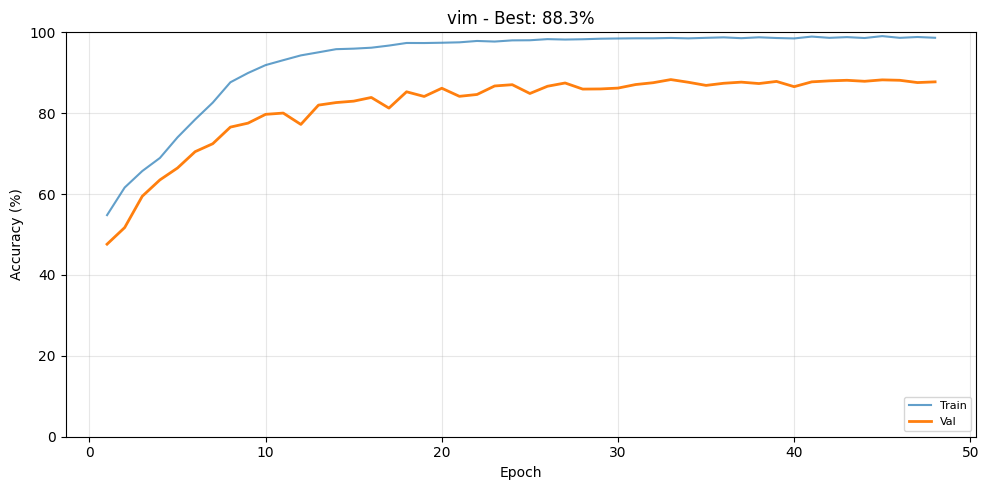

Saved vim_training_curves.png


In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for model_name, results in all_results.items():
    history = results['history']
    epochs_ran = len(history['val_acc'])
    ax.plot(range(1, epochs_ran + 1), history['train_acc'], label='Train', alpha=0.7)
    ax.plot(range(1, epochs_ran + 1), history['val_acc'], label='Val', linewidth=2)
    ax.set_title(f'{model_name} - Best: {results["best_val_acc"]:.1f}%')

ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([0, 100])
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vim_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved vim_training_curves.png')

## Noise Robustness Testing

| SNR Level | Data Source | Justification |
|---|---|---|
| clean | Held-out 20% | Avoid data leakage |
| +05dB | Held-out 20% | Avoid data leakage |
| +15dB | Held-out 20% | Avoid data leakage |
| +00dB | Full 100% | Never seen during training (validation) |
| +10dB | Full 100% | Never seen during training (test-only) |
| +20dB | Full 100% | Never seen during training (test-only) |

Metrics: Accuracy, F1 (weighted), FPR (macro), FNR (macro)

In [17]:
TASK_NUM_CLASSES = {
    'drone_type': config.num_drone_types,
    'flight_mode': config.num_flight_modes,
    'drone_count': config.num_drone_counts,
}


def compute_task_metrics(y_true, y_pred, num_classes):
    """Compute Accuracy, F1, macro-FPR, macro-FNR for a single task."""
    acc = accuracy_score(y_true, y_pred) * 100
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    fpr_list, fnr_list = [], []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
        fnr_list.append(fn / (fn + tp) if (fn + tp) > 0 else 0)
    return {
        'accuracy': acc,
        'f1': f1,
        'fpr': np.mean(fpr_list) * 100,
        'fnr': np.mean(fnr_list) * 100,
    }


@torch.no_grad()
def evaluate_on_data(model, paths, dt, fm, dc, cfg):
    """Evaluate model on given data, return per-task metrics dict."""
    if len(paths) == 0:
        return None
    ds = RFSpectrogramDataset(paths, dt, fm, dc, transform=get_val_transforms(cfg))
    loader = DataLoader(ds, batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True)
    all_preds = {t: [] for t in TASKS}
    all_labels = {t: [] for t in TASKS}
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        with autocast(dtype=torch.float16):
            logits = model(images)
        for t in TASKS:
            all_preds[t].extend(logits[t].argmax(1).cpu().tolist())
            all_labels[t].extend(labels[t].tolist())
    result = {}
    for t in TASKS:
        result[t] = compute_task_metrics(all_labels[t], all_preds[t], TASK_NUM_CLASSES[t])
    result['average'] = {
        'accuracy': np.mean([result[t]['accuracy'] for t in TASKS]),
        'f1': np.mean([result[t]['f1'] for t in TASKS]),
        'fpr': np.mean([result[t]['fpr'] for t in TASKS]),
        'fnr': np.mean([result[t]['fnr'] for t in TASKS]),
    }
    return result


def load_best_model(model_name, state_dict):
    """Instantiates model and loads saved state dict."""
    model = MODEL_REGISTRY[model_name](pretrained=False)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model


def get_eval_data(snr_level, cfg, heldout_paths, heldout_dt, heldout_fm, heldout_dc, heldout_snr):
    """Get evaluation data for an SNR level: held-out 20% for training SNRs, full data for others."""
    if snr_level in cfg.train_snr_levels:
        mask = heldout_snr == snr_level
        paths = [p for p, m in zip(heldout_paths, mask) if m]
        dt, fm, dc = heldout_dt[mask], heldout_fm[mask], heldout_dc[mask]
        source = 'held-out 20%'
    else:
        paths, dt, fm, dc, _ = load_partition(cfg.data_root, cfg.bands, (snr_level,))
        source = 'full data'
    return paths, dt, fm, dc, source


print('Evaluation utilities defined')

Evaluation utilities defined


In [18]:
print('=' * 100)
print('NOISE ROBUSTNESS EVALUATION')
print('=' * 100)

noise_results = {model_name: {} for model_name in all_results.keys()}
eval_levels = ['snr_clean', 'snr_+20dB', 'snr_+15dB', 'snr_+10dB', 'snr_+05dB', 'snr_+00dB']

for model_name, results in all_results.items():
    model = load_best_model(model_name, results['best_state'])
    print(f'\n{"=" * 100}')
    print(f'MODEL: {model_name.upper()}')
    print(f'{"=" * 100}')
    clean_paths, clean_dt, clean_fm, clean_dc, clean_src = get_eval_data(
        'snr_clean', config, heldout_paths, heldout_dt, heldout_fm, heldout_dc, heldout_snr
    )
    clean_result = evaluate_on_data(model, clean_paths, clean_dt, clean_fm, clean_dc, config)
    if clean_result:
        noise_results[model_name]['snr_clean'] = clean_result
        print(f'\n--- Clean Data ({clean_src}, n={len(clean_paths)}) ---')
        print(f'  {"Task":<15} {"Accuracy":>10} {"F1":>10} {"FPR":>10} {"FNR":>10}')
        print(f'  {"-" * 55}')
        for t in TASKS:
            m = clean_result[t]
            print(f'  {t:<15} {m["accuracy"]:>9.2f}% {m["f1"]:>9.2f}% {m["fpr"]:>9.2f}% {m["fnr"]:>9.2f}%')
        avg = clean_result['average']
        print(f'  {"AVERAGE":<15} {avg["accuracy"]:>9.2f}% {avg["f1"]:>9.2f}% {avg["fpr"]:>9.2f}% {avg["fnr"]:>9.2f}%')
    for snr in eval_levels:
        if snr == 'snr_clean':
            continue
        paths, dt, fm, dc, src = get_eval_data(
            snr, config, heldout_paths, heldout_dt, heldout_fm, heldout_dc, heldout_snr
        )
        r = evaluate_on_data(model, paths, dt, fm, dc, config)
        if r:
            noise_results[model_name][snr] = r
            print(f'\n--- {snr} ({src}, n={len(paths)}) ---')
            print(f'  {"Task":<15} {"Accuracy":>10} {"F1":>10} {"FPR":>10} {"FNR":>10}')
            print(f'  {"-" * 55}')
            for t in TASKS:
                m = r[t]
                print(f'  {t:<15} {m["accuracy"]:>9.2f}% {m["f1"]:>9.2f}% {m["fpr"]:>9.2f}% {m["fnr"]:>9.2f}%')
            avg = r['average']
            print(f'  {"AVERAGE":<15} {avg["accuracy"]:>9.2f}% {avg["f1"]:>9.2f}% {avg["fpr"]:>9.2f}% {avg["fnr"]:>9.2f}%')
    del model
    torch.cuda.empty_cache()

print('\nNoise robustness evaluation complete')

NOISE ROBUSTNESS EVALUATION

MODEL: VIM

--- Clean Data (held-out 20%, n=183) ---
  Task              Accuracy         F1        FPR        FNR
  -------------------------------------------------------
  drone_type          80.87%     81.38%      9.73%     16.92%
  flight_mode         97.81%     97.82%      0.55%      2.21%
  drone_count         86.89%     86.54%      9.52%     18.74%
  AVERAGE             88.52%     88.58%      6.60%     12.62%
  2.4GHz/snr_+20dB: 475 images
  5.8GHz/snr_+20dB: 475 images

--- snr_+20dB (full data, n=950) ---
  Task              Accuracy         F1        FPR        FNR
  -------------------------------------------------------
  drone_type          90.95%     91.01%      5.00%      9.47%
  flight_mode         99.89%     99.89%      0.03%      0.11%
  drone_count         93.26%     93.14%      5.00%      9.94%
  AVERAGE             94.70%     94.68%      3.34%      6.51%

--- snr_+15dB (held-out 20%, n=204) ---
  Task              Accuracy         F1  


NOISE ROBUSTNESS SUMMARY (Drone Type Accuracy)

Model                        clean    +20dB    +15dB    +10dB    +05dB    +00dB
------------------------------------------------------------------------------------------
vim                          80.9%    90.9%    87.7%    92.0%    84.7%    84.7%

Source                         20%     100%      20%     100%      20%     100%


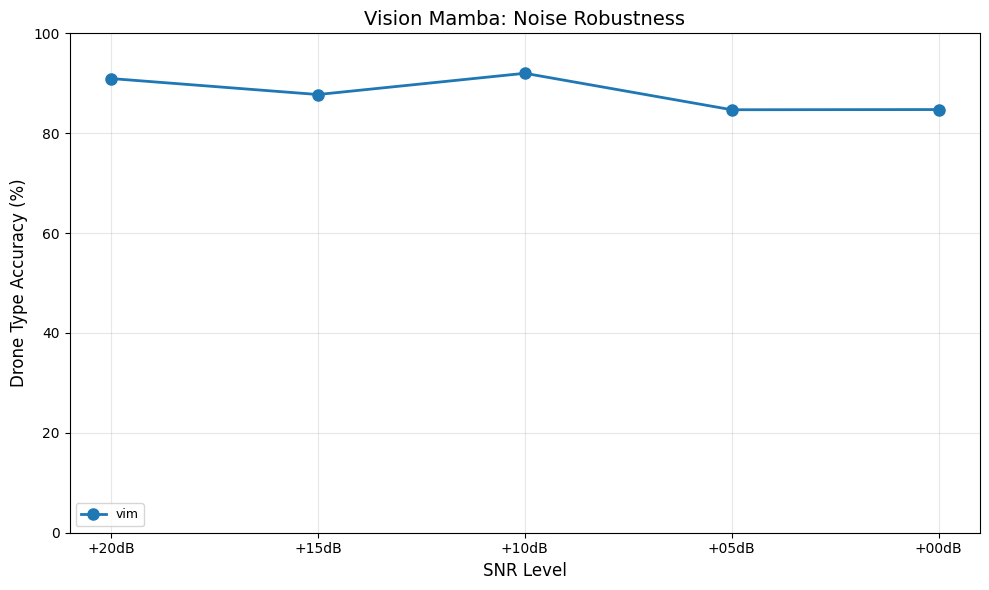

Saved vim_noise_robustness.png


In [19]:
print(f'\n{"=" * 100}')
print('NOISE ROBUSTNESS SUMMARY (Drone Type Accuracy)')
print('=' * 100)

snr_display = ['snr_clean', 'snr_+20dB', 'snr_+15dB', 'snr_+10dB', 'snr_+05dB', 'snr_+00dB']
snr_short = [s.replace('snr_', '') for s in snr_display]

print(f'\n{"Model":<25}' + ''.join(f' {s:>8}' for s in snr_short))
print('-' * 90)
for model_name in all_results.keys():
    row = f'{model_name:<25}'
    for snr in snr_display:
        if snr in noise_results[model_name]:
            acc = noise_results[model_name][snr]['drone_type']['accuracy']
            row += f' {acc:7.1f}%'
        else:
            row += '     N/A'
    print(row)

print(f'\n{"Source":<25}' + ''.join(
    f' {"20%":>8}' if s in config.train_snr_levels else f' {"100%":>8}' for s in snr_display
))

fig, ax = plt.subplots(figsize=(10, 6))

snr_order = ['snr_+20dB', 'snr_+15dB', 'snr_+10dB', 'snr_+05dB', 'snr_+00dB']
snr_labels_plot = ['+20dB', '+15dB', '+10dB', '+05dB', '+00dB']
colors = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

for idx, (model_name, _) in enumerate(all_results.items()):
    accs = []
    for snr in snr_order:
        if snr in noise_results[model_name]:
            accs.append(noise_results[model_name][snr]['drone_type']['accuracy'])
        else:
            accs.append(np.nan)
    ax.plot(range(len(snr_order)), accs, 'o-', label=model_name, color=colors[idx], linewidth=2, markersize=8)

ax.set_xlabel('SNR Level', fontsize=12)
ax.set_ylabel('Drone Type Accuracy (%)', fontsize=12)
ax.set_title('Vision Mamba: Noise Robustness', fontsize=14)
ax.set_xticks(range(len(snr_order)))
ax.set_xticklabels(snr_labels_plot)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('vim_noise_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved vim_noise_robustness.png')

## Save Artifacts

In [20]:
OUTPUT_DIR = 'vim_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Saving Vision Mamba artifacts...')
for model_name, results in all_results.items():
    torch.save(results['best_state'], f'{OUTPUT_DIR}/best_{model_name}.pth')
    print(f'  {model_name}: Acc={results["best_val_acc"]:.2f}%')

results_summary = {
    'model': 'vision_mamba',
    'timestamp': datetime.now().isoformat(),
    'training_strategy': 'noise_robust',
    'architecture': {
        'embed_dim': config.embed_dim,
        'depth': config.depth,
        'patch_size': config.patch_size,
        'd_state': config.d_state,
        'd_conv': config.d_conv,
        'expand': config.expand,
    },
    'train_snr': list(config.train_snr_levels),
    'val_snr': list(config.val_snr_levels),
    'test_snr': list(config.test_snr_levels),
    'config': {
        'batch_size': config.batch_size,
        'learning_rate': config.learning_rate,
        'epochs': config.epochs,
        'patience': config.patience,
    },
    'models': {
        name: {
            'best_val_acc': r['best_val_acc'],
            'per_task': {
                task: {
                    'accuracy': r['best_metrics'][task]['accuracy'],
                    'f1_score': r['best_metrics'][task]['f1_score'],
                } for task in TASKS
            }
        } for name, r in all_results.items()
    },
    'noise_robustness': {
        model_name: {
            snr: {
                t: {k: round(v, 2) for k, v in data[t].items()} if isinstance(data[t], dict) else round(data[t], 2)
                for t in list(TASKS) + ['average']
            }
            for snr, data in snr_data.items()
        } for model_name, snr_data in noise_results.items()
    },
}

with open(f'{OUTPUT_DIR}/vim_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print('Saved vim_results_summary.json')

with open(f'{OUTPUT_DIR}/vim_histories.pkl', 'wb') as f:
    pickle.dump({name: r['history'] for name, r in all_results.items()}, f)
print('Saved vim_histories.pkl')

with open(f'{OUTPUT_DIR}/vim_noise_results.pkl', 'wb') as f:
    pickle.dump(noise_results, f)
print('Saved vim_noise_results.pkl')

if os.path.exists('vim_training_curves.png'):
    shutil.copy('vim_training_curves.png', f'{OUTPUT_DIR}/vim_training_curves.png')
    print('Saved vim_training_curves.png')

if os.path.exists('vim_noise_robustness.png'):
    shutil.copy('vim_noise_robustness.png', f'{OUTPUT_DIR}/vim_noise_robustness.png')
    print('Saved vim_noise_robustness.png')

zip_name = f'vim_training_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
shutil.make_archive(zip_name, 'zip', OUTPUT_DIR)
print(f'\n{"=" * 70}')
print(f'ZIP CREATED: {zip_name}.zip')
print('=' * 70)
print(f'\nContents: {os.listdir(OUTPUT_DIR)}')

try:
    from IPython.display import FileLink, display
    display(FileLink(f'{zip_name}.zip'))
except ImportError:
    print(f'Download: {os.path.abspath(zip_name)}.zip')

Saving Vision Mamba artifacts...
  vim: Acc=88.32%
Saved vim_results_summary.json
Saved vim_histories.pkl
Saved vim_noise_results.pkl
Saved vim_training_curves.png
Saved vim_noise_robustness.png

ZIP CREATED: vim_training_20260212_102636.zip

Contents: ['vim_histories.pkl', 'vim_noise_results.pkl', 'vim_training_curves.png', 'vim_noise_robustness.png', 'best_vim.pth', 'vim_results_summary.json']


/kaggle/working/vim_training_20260212_102636.zip